In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
url = "https://raw.githubusercontent.com/lutzhamel/fake-news/master/data/fake_or_real_news.csv"

df = pd.read_csv(url)
df.head()

,id,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [3]:
X = df["text"]
y = df["label"]

In [4]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(X)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [6]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9179163378058406


In [7]:
probs = model.predict_proba(X_test)

confidence = np.max(probs, axis=1)

print("Average Confidence:", np.mean(confidence))

Average Confidence: 0.8098508841330684


In [8]:
low_conf_idx = np.where(confidence < 0.6)[0]

print("Low confidence predictions:", len(low_conf_idx))

Low confidence predictions: 126


In [11]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Logistic Regression Accuracy: 0.9179163378058406
Decision Tree Accuracy: 0.8034727703235991


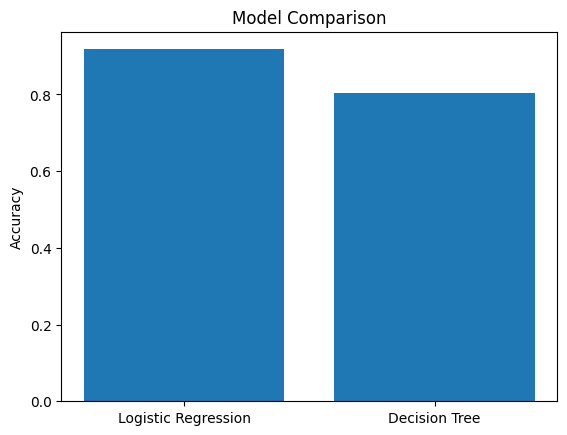

In [12]:
models = ["Logistic Regression", "Decision Tree"]
scores = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, dt_pred)
]

import matplotlib.pyplot as plt

plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

## Model Comparison

I compared Logistic Regression with a Decision Tree model to see how performance differs. 

Logistic Regression performed more consistently, while Decision Tree showed variation. This comparison helps understand model behavior better rather than relying on a single approach.

## Reliability Analysis

The model gives a decent overall accuracy, but when I looked at prediction confidence, I noticed that it is not consistent for all samples.

Some predictions have low confidence (below 0.6), which means the model is not very sure about those outputs. These cases are important because they show where the model may not be reliable.

This shows that even if a model performs well overall, it can still struggle in certain situations. Using confidence scores helps identify such cases and is useful when building more trustworthy systems.